In [2]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import PCGP.gpytorch_tools as gt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
from matplotlib import cm  # Colormaps
from matplotlib import gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

plt.rcParams.update({'font.size': 22})
base_dir = os.getcwd()

save_dir = os.path.join(base_dir, "graphs")
data_dir_ex2 = os.path.join(base_dir,  "Experiment2_Tripendulum", "output_data")
sim_data_dir_ex2 = os.path.join(base_dir,  "Experiment2_Tripendulum", "input_data")
graph_abstract = os.path.join(base_dir,  "Experiment2_Tripendulum", "graphical_abstract", "output")

torch.Size([804])
torch.Size([1005])
torch.Size([1206])


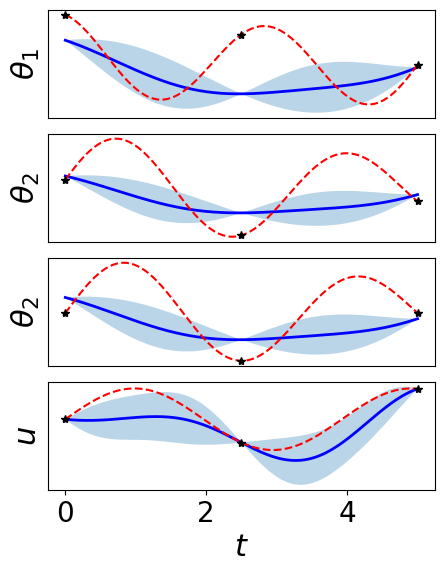

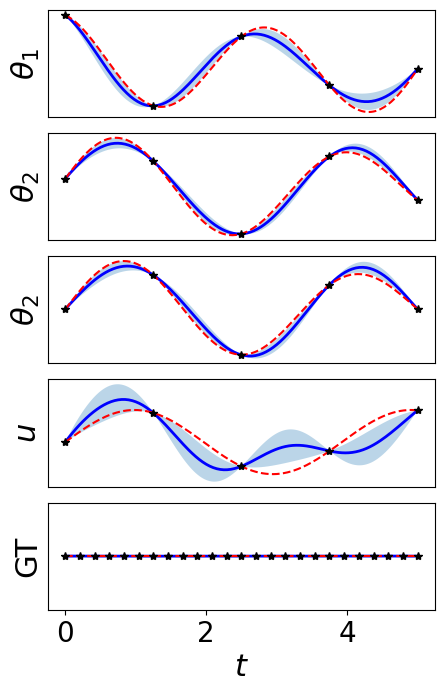

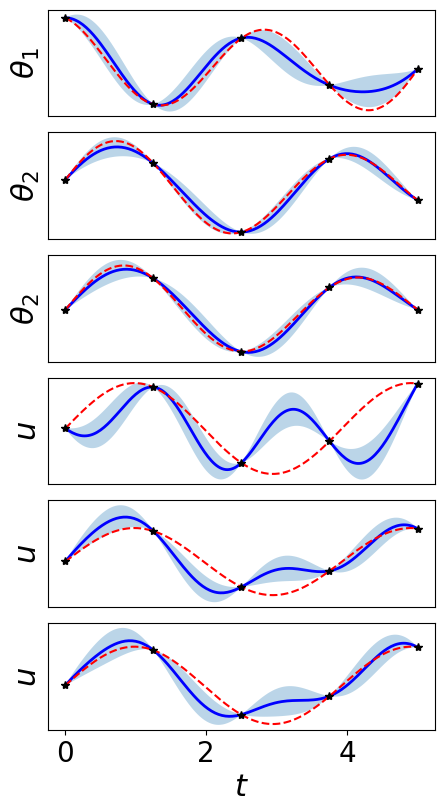

In [45]:
task_labels = [r"$\theta_1$", r"$\theta_2$", r"$\theta_2$", r"$u$", r"$u$", r"$u$"]  
modes = [ "NSB", "GT", "PIGP"]
Al_mode = "withAl"
sigma_mode = ""
npoints = 5
run = 3
sigma = 0.01
n_tasks = {"NSB":4, "GT":5, "PIGP":6}
for mode in modes:
    if mode !="NSB":
        data_ex2 = np.load(os.path.join(data_dir_ex2, "shared_kernel", Al_mode, f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
    else:
        data_ex2 = np.load(os.path.join(graph_abstract,
                                        f"reference_n%i.npz"%npoints))
    for key in data_ex2:
                    globals()[key] = torch.tensor(data_ex2[key])
    num_tasks = n_tasks[mode]
    height_per_axis = 1.2
    bottom_margin = 0.8     # space for xlabel
    top_margin = 0.3
    hspace = 0.15
    
    fig_height = (
        num_tasks * height_per_axis
        + bottom_margin
        + top_margin
    )
    
    fig, ax = plt.subplots(
        num_tasks,
        1,
        sharex=True,
        figsize=(5, fig_height),
        gridspec_kw={"hspace": hspace}
    )

    for i in range(num_tasks):
                ax[i].plot(test_x[test_x[:,-1]==i, 0], mean[test_x[:,-1]==i], 'b', linewidth=2)
                ax[i].fill_between(test_x[test_x[:,-1]==i, 0], lower[test_x[:,-1]==i], upper[test_x[:,-1]==i], alpha=0.3)
                ax[i].plot(test_x[test_x[:,-1]==i,0], test_y[test_x[:,-1]==i], "r--")
                #mask = ~torch.isnan(train_y[:, i])
                ax[i].plot(train_x[train_x[:,-1]==i,0], train_y[train_x[:,-1]==i], 'k*')
                if mode == "GT":
                        ax[i].set_ylabel(task_labels[i] if i < 4 else f"GT", fontsize=22)
                        ax[-1].set_ylim([-0.02, +0.02])
                else:
                    ax[i].set_ylabel(task_labels[i] if i < len(task_labels) else f"GT", fontsize=22)
                if i < num_tasks - 1:
                    ax[i].tick_params(labelbottom=False, bottom = False, labelsize=20)
                    ax[i].set_yticks([])
                else:
                    if mode == "GT":
                        ax[i].set_ylim((-1, 1))
                    ax[i].set_xlabel(r"$t$", fontsize=22)
                    ax[i].tick_params(labelsize=20)
                   
                    ax[i].set_yticks([])
                    
    fig.subplots_adjust(
    bottom=bottom_margin / fig_height,
    top=1 - top_margin / fig_height
)
   # plt.savefig(os.path.join(save_dir, "graphical_abstract_%s.png"%mode), dpi=300,bbox_inches='tight')

# Error metric: absolute value of MAP parameter estimate error relative to parameter size

Todo: average over all runs, not just one shot? -> i need mean and variance

{'Parameter 1': tensor([0.0000, 0.0706, 0.0030]), 'Parameter 2': tensor([0.0000, 0.5770, 0.0007]), 'Ratio': tensor([4.4409e-16, 1.7291e-01, 1.5711e-02])}


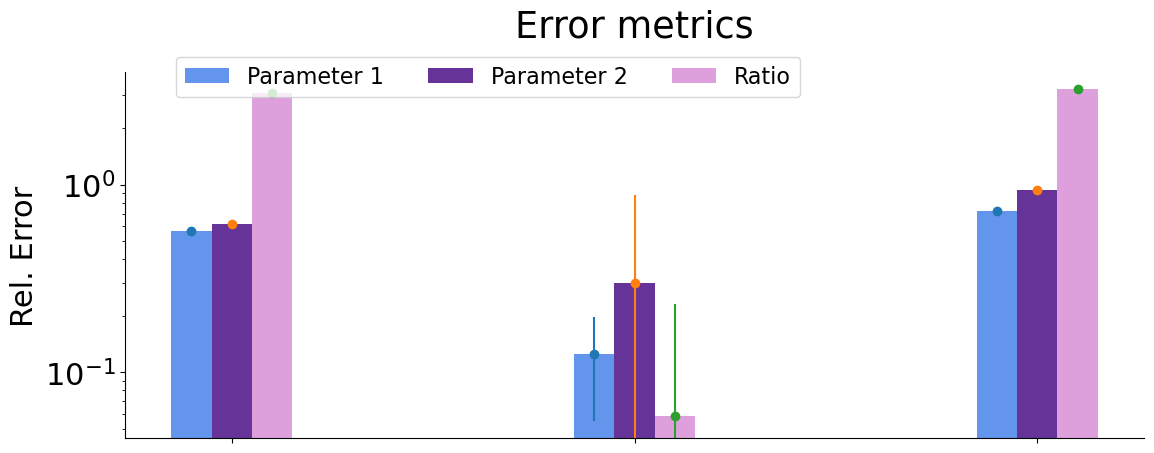

In [11]:
sigma = 0.01
npoints = 3
modes = ["NSB", "GT", "PIGP"]
num_tasks_list = [5, 6, 4]  # given
run = 3

Al_mode = "withAl"
runs = 10
means = {}
stds = {}
delta1_mean, delta2_mean, delta3_mean = [],[],[]
delta1_std, delta2_std, delta3_std = [],[],[]
for mode in modes:
    delta_l = np.zeros(runs)
    delta_g = np.zeros(runs)
    delta_r = np.zeros(runs)
    for run in range(runs): ##
        if mode !="NSB":
            data_ex2 = np.load(os.path.join(data_dir_ex2, "shared_kernel", Al_mode, f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
        else:
            data_ex2 = np.load(os.path.join(graph_abstract,
                                            f"reference_n%i_sigma%.2f.npz"%(npoints, sigma)))
        for key in data_ex2:
                globals()[key] = torch.tensor(data_ex2[key])
        delta_l[run] = abs(learned_parameters[0]-true_parameters[0])/true_parameters[0]
        delta_g[run] = abs(learned_parameters[1]-true_parameters[1])/true_parameters[1]
        delta_r[run] = abs(learned_parameters[0]/learned_parameters[1]-true_parameters[0]/true_parameters[1])/(true_parameters[0]/true_parameters[1])
    
    delta1_mean.append(np.mean(delta_l))
    delta2_mean.append(np.mean(delta_g))
    delta3_mean.append(np.mean(delta_r))
    delta1_std.append(np.sqrt(np.var(delta_l)))
    delta2_std.append(np.sqrt(np.var(delta_g)))
    delta3_std.append(np.sqrt(np.var(delta_r)))
    
means[r"""Parameter 1"""] = torch.Tensor(delta1_mean)
means[r"""Parameter 2"""] = torch.Tensor(delta2_mean)
means[r"""Ratio"""] = torch.Tensor(delta3_mean)
stds[r"""Parameter 1"""] = torch.Tensor(delta1_std)
stds[r"""Parameter 2"""] = torch.Tensor(delta2_std)
stds[r"""Ratio"""] = torch.Tensor(delta3_std)
print(stds)

#formatting
metrics = list(means.keys())  # ["Δℓ", "Δg", "Δ(ℓ/g)"]
x = np.arange(len(modes))    # groups = modes
width = 0.1
colors = ["cornflowerblue", "rebeccapurple", "plum"]
fig, ax = plt.subplots(figsize=(12, 5))


for i, metric in enumerate(metrics):
    values = means[metric]   # one value per mode
    err = stds[metric]
    offset = (i - 1) * width   # center the 3 bars
    rects = ax.bar(x + offset, values, width, label=metric, color = colors[i])
    ax.errorbar(x+offset, values, yerr = err, marker = "o", linestyle = "none")
    #ax.bar_label(rects, padding=3, fontsize=10)

#formatting
ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_title("Error metrics", pad = 25)
ax.set_yscale("log")
ax.set_ylabel("Rel. Error")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(ncols = 3, fontsize = 16, loc = (.05, 0.93))
plt.tight_layout(h_pad = 2)

#plt.savefig(os.path.join(save_dir, "graphical_abstract_error.png"), dpi=300,bbox_inches='tight')

## One shot aka one run variante ohne errorbars

NSB tensor([1.4156, 6.0409]) tensor(0.7840)
GT tensor([0.3625, 1.4268]) tensor(0.0001)
PIGP tensor([1.8133, 9.1771]) tensor(0.8302)


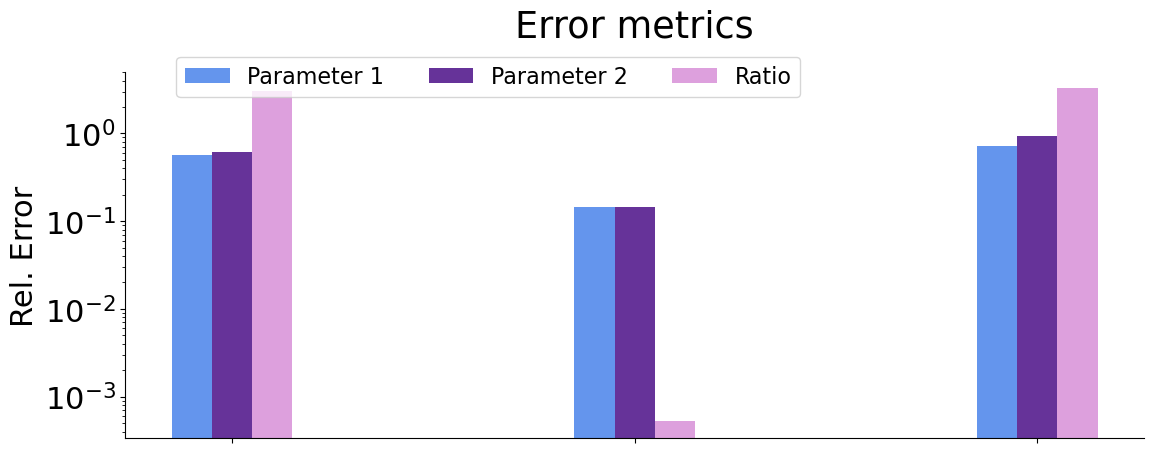

In [73]:
sigma = 0.01
npoints = 3
modes = ["NSB", "GT", "PIGP"]
num_tasks_list = [5, 6, 4]  # given
run = 3
colors = ["cornflowerblue", "rebeccapurple", "plum"]
Al_mode = "withAl"
sigma_mode = "extraGTsigma"
point_mode = "extraGTpoints"
data = {}
delta1, delta2, delta3 = [],[],[]
for mode in modes:
    if mode !="NSB":
        data_ex2 = np.load(os.path.join(data_dir_ex2, "shared_kernel", Al_mode, f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
    else:
        data_ex2 = np.load(os.path.join(graph_abstract,
                                        f"reference_n%i_sigma%.2f.npz"%(npoints, sigma)))
    for key in data_ex2:
            globals()[key] = torch.tensor(data_ex2[key])
    delta1.append(abs(learned_parameters[0]-true_parameters[0]))
    delta2.append(abs(learned_parameters[1]-true_parameters[1]))
    delta3.append(abs(learned_parameters[0]/learned_parameters[1]-true_parameters[0]/true_parameters[1]))
    print(mode, abs(learned_parameters-true_parameters), abs(learned_parameters[0]/learned_parameters[1]-true_parameters[0]/true_parameters[1]))
    #data[mode]=(abs(learned_parameters[0]-true_parameters[0]), abs(learned_parameters[1]-true_parameters[1]), abs(learned_parameters[0]/learned_parameters[1]-true_parameters[0]/true_parameters[1]))
data[r"""Parameter 1"""] = torch.Tensor(delta1)/true_parameters[0]
data[r"""Parameter 2"""] = torch.Tensor(delta2)/true_parameters[1]
data[r"""Ratio"""] = torch.Tensor(delta3)/(true_parameters[0]/true_parameters[1])

metrics = list(data.keys())  # ["Δℓ", "Δg", "Δ(ℓ/g)"]

x = np.arange(len(modes))    # groups = modes
width = 0.1

fig, ax = plt.subplots(figsize=(12, 5))

for i, metric in enumerate(metrics):
    values = data[metric]   # one value per mode
    offset = (i - 1) * width   # center the 3 bars
    rects = ax.bar(x + offset, values, width, label=metric, color = colors[i])
    #ax.bar_label(rects, padding=3, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_title("Error metrics", pad = 25)
ax.set_yscale("log")
ax.set_ylabel("Rel. Error")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(ncols = 3, fontsize = 16, loc = (.05, 0.93))
plt.tight_layout(h_pad = 2)
#plt.savefig(os.path.join(save_dir, "graphical_abstract_error.png"), dpi=300,bbox_inches='tight')